# Tech Challenge 9IADT - Fase 2
> Thiago de Melo Lima - RM370763 - Whatsapp: 11949389623

## 🧠 Dados e Modelos

#### O sistema ***dIAbetes***, será capaz de ajudar médicos(as) e equipes clínicas na análise inicial de exames e no processamento de dados médicos com o objetivo de prever, com base em medições diagnósticas, se um paciente tem diabetes ou não.

## 📊 Dataset sobre Diabetes que será utilizado:

Essa base de dados contém **768 registros** com informações sobre características pessoais e fatores que podem influenciar o diagnostico de diabetes em um paciente.

> [clique aqui para mais informações sobre o dataset](https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data)
---



# Importação das biblietecas e referências do projeto

In [222]:
#importação das biblietecas e referencias do projeto
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from ollama import chat




# Modelo Original Sem Otimização

In [223]:
df_dIAbetes = pd.read_csv("../dataset/raw/diabetes.csv", low_memory=False) #carregando a base de dados

In [224]:
# features escolhidas para o diagnóstico
vars_diagnostico=['Glucose','BMI','Age','Pregnancies','DiabetesPedigreeFunction']

X = df_dIAbetes[vars_diagnostico] #variaveis independentes
y = df_dIAbetes['Outcome'] #target

Em seguida, dividimos os dados em treino e teste, utilizando 80% para treino e 20% para teste:

In [225]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.2, #20% para teste e 80% de treino
                                                     stratify=y, #distribuir de forma igual entre treino e teste
                                                     random_state=7) #semente aleatoria
print(X_train.shape)
print(X_test.shape)

(614, 5)
(154, 5)


# Pipeline Random Forest (com SMOTE)

In [226]:
pipeline_random_forest = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=7)),
    ('model', RandomForestClassifier(
        criterion='entropy',
        n_estimators=80,
        max_depth=2,
        class_weight='balanced',
        random_state=7
    ))
])

pipeline_random_forest.fit(X_train, y_train)

y_pred_random_forest = pipeline_random_forest.predict(X_test)

In [227]:
y_predito_random_forest = pipeline_random_forest.predict(X_test) 
y_predito_random_forest

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [228]:
# Metricas de precisão, revocação, f1-score e acurácia.
acuracia_base = accuracy_score(y_test, y_pred_random_forest)
precisao_base = precision_score(y_test, y_pred_random_forest)
recall_base = recall_score(y_test, y_pred_random_forest)
f1_base = f1_score(y_test, y_pred_random_forest)

print("Modelo Base - Random Forest")
print(f"Acurácia: {acuracia_base:.4f}")
print(f"Precisão: {precisao_base:.4f}")
print(f"Recall: {recall_base:.4f}")
print(f"F1-Score: {f1_base:.4f}")

matriz_confusao = confusion_matrix(y_test, y_pred_random_forest)

tn, fp, fn, tp = matriz_confusao.ravel()

especificidade_base = tn / (tn + fp)

print(f"Especificidade: {especificidade_base:.4f}")

Modelo Base - Random Forest
Acurácia: 0.8052
Precisão: 0.7000
Recall: 0.7778
F1-Score: 0.7368
Especificidade: 0.8200


## Resultado baseline salvo para futuras comparações

In [229]:
resultado_modelo_base = {
    "acuracia": acuracia_base,
    "precisao": precisao_base,
    "recall": recall_base,
    "f1_score": f1_base,
    "especificidade": especificidade_base
}

resultado_modelo_base

{'acuracia': 0.8051948051948052,
 'precisao': 0.7,
 'recall': 0.7777777777777778,
 'f1_score': 0.7368421052631579,
 'especificidade': np.float64(0.82)}

Na Fase 1 foi desenvolvido um modelo de Machine Learning para predição de diabetes, sendo o algoritmo **Random Forest** selecionado como modelo base por apresentar o melhor equilíbrio entre as métricas de avaliação. O modelo alcançou **81% de acurácia**, **70% de precisão**, **78% de recall** e **74% de F1-Score** para a classe positiva (pacientes diabéticos), além de **87% de precisão**, **82% de recall** e **85% de F1-Score** para a classe negativa.

Esses resultados demonstram uma boa capacidade de classificação de pacientes com maior probabilidade de diabetes, tornando o modelo adequado como ferramenta de apoio à decisão médica. Entretanto, ainda existem oportunidades de melhoria, principalmente na redução de falsos negativos e no aperfeiçoamento das métricas de classificação.

Dessa forma, nesta segunda fase, esse modelo será utilizado como ponto de partida para aplicação de **Algoritmos Genéticos**, com o objetivo de encontrar automaticamente uma combinação de hiperparâmetros que proporcione melhor desempenho e, posteriormente, integrá-lo a uma **Large Language Model (LLM)** para geração de explicações em linguagem natural.


# OTIMIZAÇÃO DE HIPERPARÂMETROS COM ALGORITMO GENÉTICO


O modelo base da Fase 1 utilizava n_estimators=80 e max_depth=2. Na Fase 2 vai ser implementado um algoritmo genético para encontrar automaticamente os melhores valores para esses hiperparâmetros, mantendo os demais parâmetros inalterados.

## função de gerar individuos

In [230]:
def gerar_individuo():
    """
    Gera um indivíduo aleatório para o Algoritmo Genético.

    Gene 1: quantidade de árvores (n_estimators)
    Gene 2: profundidade máxima (max_depth)
    """

    n_estimators = random.randint(
        20,
        200
    )

    max_depth = random.randint(
        1,
        20
    )

    return [
        n_estimators,
        max_depth
    ]

## Teste Unitário - gerar_individuo()

In [231]:
def testar_gerar_individuo():

    individuo = gerar_individuo()

    assert isinstance(
        individuo,
        list
    ), "O indivíduo deve ser uma lista."

    assert len(
        individuo
    ) == 2, "O indivíduo deve possuir exatamente 2 genes."

    assert 20 <= individuo[0] <= 200, (
        "n_estimators deve estar entre 20 e 200."
    )

    assert 1 <= individuo[1] <= 20, (
        "max_depth deve estar entre 1 e 20."
    )

    print(
        "✓ Teste unitário da função gerar_individuo() executado com sucesso."
    )


# Executando o teste
testar_gerar_individuo()

✓ Teste unitário da função gerar_individuo() executado com sucesso.


## função de calcular fitness

In [232]:
def calcular_fitness(individuo):
    """
    Calcula o fitness de um indivíduo utilizando
    Recall, F1-Score e Especificidade.
    """

    n_estimators, max_depth = individuo

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=7)),
        ('model', RandomForestClassifier(
            criterion='entropy',
            class_weight='balanced',
            random_state=7,
            n_estimators=n_estimators,
            max_depth=max_depth
        ))
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    especificidade = tn / (tn + fp)

    fitness = (
        (0.7 * recall) +
        (0.1 * precision) +
        (0.1 * especificidade)
    )

    return fitness

## Teste Unitário - calcular_fitness()

In [233]:
def testar_calcular_fitness():

    individuo = [
        80,  # n_estimators
        2    # max_depth
    ]

    fitness = calcular_fitness(
        individuo
    )

    assert isinstance(
        fitness,
        float
    ), "O fitness deve ser um número decimal."

    assert 0 <= fitness <= 1, (
        "O fitness deve estar entre 0 e 1."
    )

    print(
        "✓ Teste unitário da função calcular_fitness() executado com sucesso."
    )


# Executando o teste
testar_calcular_fitness()

✓ Teste unitário da função calcular_fitness() executado com sucesso.


## função de selecionar pais

In [234]:
def selecionar_pais(
    populacao_avaliada,
    tamanho_torneio=3
):
    """
    Seleciona o melhor indivíduo entre os candidatos
    utilizando seleção por torneio.
    """

    candidatos = random.sample(
        populacao_avaliada,
        tamanho_torneio
    )

    melhor_individuo = max(
        candidatos,
        key=lambda candidato: candidato[1]
    )

    return melhor_individuo[0]

## Teste Unitário - selecionar_pais()

In [235]:
def testar_selecionar_pais():

    populacao_avaliada = [
        ([80, 2], 0.72),
        ([100, 4], 0.75),
        ([120, 6], 0.78),
        ([150, 8], 0.74)
    ]

    pai = selecionar_pais(
        populacao_avaliada
    )

    assert isinstance(
        pai,
        list
    ), "O pai selecionado deve ser uma lista."

    assert len(
        pai
    ) == 2, (
        "O indivíduo deve possuir exatamente 2 genes."
    )

    individuos = [
        individuo
        for individuo, _ in populacao_avaliada
    ]

    assert pai in individuos, (
        "O indivíduo selecionado deve pertencer à população."
    )

    print(
        "✓ Teste unitário da função selecionar_pais() executado com sucesso."
    )


# Executando o teste
testar_selecionar_pais()

✓ Teste unitário da função selecionar_pais() executado com sucesso.


## função de cruzamento

In [236]:
def cruzar(
    pai1,
    pai2
):
    """
    Realiza o cruzamento entre dois pais,
    combinando um gene de cada indivíduo
    para gerar dois novos filhos.
    """

    filho1 = [
        pai1[0],  # n_estimators
        pai2[1]   # max_depth
    ]

    filho2 = [
        pai2[0],  # n_estimators
        pai1[1]   # max_depth
    ]

    return (
        filho1,
        filho2
    )

## Teste Unitário - cruzar()

In [237]:
def testar_cruzar():

    pai1 = [80, 2]
    pai2 = [120, 6]

    filho1, filho2 = cruzar(
        pai1,
        pai2
    )

    # =====================================================
    # Tipo
    # =====================================================

    assert isinstance(
        filho1,
        list
    ), "O filho 1 deve ser uma lista."

    assert isinstance(
        filho2,
        list
    ), "O filho 2 deve ser uma lista."

    # =====================================================
    # Quantidade de genes
    # =====================================================

    assert len(
        filho1
    ) == 2, (
        "O filho 1 deve possuir 2 genes."
    )

    assert len(
        filho2
    ) == 2, (
        "O filho 2 deve possuir 2 genes."
    )

    # =====================================================
    # Cruzamento
    # =====================================================

    assert filho1 == [80, 6], (
        "O filho 1 foi gerado incorretamente."
    )

    assert filho2 == [120, 2], (
        "O filho 2 foi gerado incorretamente."
    )

    print(
        "✓ Teste unitário da função cruzar() executado com sucesso."
    )


# Executando o teste
testar_cruzar()

✓ Teste unitário da função cruzar() executado com sucesso.


## função de mutação de individuos

In [238]:
def calcular_taxa_mutacao(
    taxa_mutacao,
    geracoes_sem_melhora
):
    """
    Calcula a taxa de mutação adaptativa.
    """

    if geracoes_sem_melhora < 3:

        return taxa_mutacao

    return min(
        1.0,
        taxa_mutacao +
        ((geracoes_sem_melhora - 2) * 0.2)
    )

## Teste Unitário - calcular_taxa_mutacao()

In [239]:
def testar_calcular_taxa_mutacao():

    # =====================================================
    # Sem estagnação
    # =====================================================

    assert calcular_taxa_mutacao(0.2, 0) == 0.2

    assert calcular_taxa_mutacao(0.2, 1) == 0.2

    assert calcular_taxa_mutacao(0.2, 2) == 0.2

    # =====================================================
    # Mutação adaptativa
    # =====================================================

    assert calcular_taxa_mutacao(0.2, 3) == 0.4

    assert calcular_taxa_mutacao(0.2, 4) == 0.6

    assert calcular_taxa_mutacao(0.2, 5) == 0.8

    assert calcular_taxa_mutacao(0.2, 6) == 1.0

    # =====================================================
    # Limite máximo
    # =====================================================

    assert calcular_taxa_mutacao(0.2, 7) == 1.0

    assert calcular_taxa_mutacao(0.2, 20) == 1.0

    print(
        "✓ Teste unitário da função calcular_taxa_mutacao() executado com sucesso."
    )


    # Executando o teste
    testar_calcular_taxa_mutacao()

In [240]:
def mutar(
    individuo,
    taxa_mutacao=0.2,
    geracoes_sem_melhora=0
):
    """
    Realiza a mutação de um indivíduo.

    Caso o algoritmo permaneça estagnado por
    três ou mais gerações consecutivas,
    a taxa de mutação é aumentada
    progressivamente.
    """

    novo_individuo = individuo.copy()

    # ==========================================
    # Mutação adaptativa progressiva
    # ==========================================

    taxa_mutacao = calcular_taxa_mutacao(
        taxa_mutacao,
        geracoes_sem_melhora
    )
    
    
    # ==========================================
    # Mutação
    # ==========================================

    if random.random() < taxa_mutacao:

        indice_gene = random.randint(0, 1)

        if indice_gene == 0:

            novo_valor = individuo[0]

            while novo_valor == individuo[0]:

                novo_valor = random.randint(
                    20,
                    200
                )

            novo_individuo[0] = novo_valor

        else:

            novo_valor = individuo[1]

            while novo_valor == individuo[1]:

                novo_valor = random.randint(
                    1,
                    20
                )

            novo_individuo[1] = novo_valor

    return novo_individuo

## Teste Unitário - mutar()

In [241]:
def testar_mutar():

    individuo = [80, 2]

    # =====================================================
    # Sem mutação
    # =====================================================

    individuo_sem_mutacao = mutar(
        individuo,
        taxa_mutacao=0,
        geracoes_sem_melhora=0
    )

    assert individuo_sem_mutacao == individuo, (
        "O indivíduo não deveria sofrer mutação."
    )

    # =====================================================
    # Mutação normal (100%)
    # =====================================================

    individuo_mutado = mutar(
        individuo,
        taxa_mutacao=1,
        geracoes_sem_melhora=0
    )

    assert isinstance(
        individuo_mutado,
        list
    ), "O indivíduo mutado deve ser uma lista."

    assert len(
        individuo_mutado
    ) == 2, (
        "O indivíduo mutado deve possuir 2 genes."
    )

    assert 20 <= individuo_mutado[0] <= 200, (
        "n_estimators inválido após mutação."
    )

    assert 1 <= individuo_mutado[1] <= 20, (
        "max_depth inválido após mutação."
    )

    assert individuo_mutado != individuo, (
        "A mutação deveria alterar pelo menos um gene."
    )

    # =====================================================
    # Mutação adaptativa (estagnação)
    # =====================================================

    individuo_adaptativo = mutar(
        individuo,
        taxa_mutacao=0.2,
        geracoes_sem_melhora=5
    )

    assert isinstance(
        individuo_adaptativo,
        list
    ), "O indivíduo mutado deve ser uma lista."

    assert len(
        individuo_adaptativo
    ) == 2, (
        "O indivíduo mutado deve possuir 2 genes."
    )

    assert 20 <= individuo_adaptativo[0] <= 200, (
        "n_estimators inválido após mutação adaptativa."
    )

    assert 1 <= individuo_adaptativo[1] <= 20, (
        "max_depth inválido após mutação adaptativa."
    )

    print(
        "✓ Teste unitário da função mutar() executado com sucesso."
    )


# Executando o teste
testar_mutar()

✓ Teste unitário da função mutar() executado com sucesso.


## função de execução do algoritmo genético

In [242]:
def executar_algoritmo_genetico(
    tamanho_populacao=20,
    numero_geracoes=10,
    taxa_mutacao=0.2,
    exibir_progresso=True
):
    """
    Executa o Algoritmo Genético para otimização dos
    hiperparâmetros do Random Forest.
    """

    # =====================================================
    # População inicial
    # =====================================================

    populacao = [
        gerar_individuo()
        for _ in range(tamanho_populacao)
    ]

    melhor_individuo = None
    melhor_fitness = 0

    geracoes_sem_melhora = 0

    historico_melhor = []
    historico_medio = []
    historico_pior = []

    # =====================================================
    # Evolução
    # =====================================================

    for geracao in range(numero_geracoes):

        # =================================================
        # Avaliação da população
        # =================================================

        populacao_avaliada = [
            (
                individuo,
                calcular_fitness(individuo)
            )
            for individuo in populacao
        ]

        populacao_avaliada.sort(
            key=lambda individuo: individuo[1],
            reverse=True
        )

        melhor_da_geracao = populacao_avaliada[0][0]
        fitness_da_geracao = populacao_avaliada[0][1]

        # =================================================
        # Estatísticas da geração
        # =================================================

        fitness_populacao = [
            fitness
            for _, fitness in populacao_avaliada
        ]

        menor_fitness = min(
            fitness_populacao
        )

        fitness_medio = (
            sum(fitness_populacao)
            / len(fitness_populacao)
        )

        maior_fitness = max(
            fitness_populacao
        )

        historico_melhor.append(
            maior_fitness
        )

        historico_medio.append(
            fitness_medio
        )

        historico_pior.append(
            menor_fitness
        )

        # =================================================
        # Log da geração
        # =================================================

        if exibir_progresso:

            taxa_atual = calcular_taxa_mutacao(
                taxa_mutacao,
                geracoes_sem_melhora
            )

            print(
                f"Geração {geracao + 1:02d} | "
                f"Menor fitness: {menor_fitness:.4f} | "
                f"Fitness médio: {fitness_medio:.4f} | "
                f"Melhor fitness: {maior_fitness:.4f} | "
                f"Mutação: {taxa_atual:.1f} | "
                f"Indivíduo: {melhor_da_geracao}"
            )

            if geracoes_sem_melhora >= 3:

                print(
                    f"⚠ Nenhuma melhoria nas últimas "
                    f"{geracoes_sem_melhora} gerações. "
                    f"Taxa de mutação ajustada para "
                    f"{taxa_atual:.1f}."
                )

        # =================================================
        # Atualiza melhor solução encontrada
        # =================================================

        if fitness_da_geracao > melhor_fitness:

            melhor_fitness = fitness_da_geracao

            melhor_individuo = melhor_da_geracao.copy()

            if (
                geracoes_sem_melhora >= 3
                and exibir_progresso
            ):

                print(
                    "✓ Melhoria encontrada. "
                    "Retornando para a taxa de mutação padrão."
                )

            geracoes_sem_melhora = 0

        else:

            geracoes_sem_melhora += 1

        # =================================================
        # Elitismo
        # =================================================

        nova_populacao = [
            melhor_da_geracao.copy()
        ]

        while len(nova_populacao) < tamanho_populacao:

            pai1 = selecionar_pais(
                populacao_avaliada
            )

            pai2 = selecionar_pais(
                populacao_avaliada
            )

            tentativas = 0

            while (
                pai1 == pai2
                and tentativas < 5
            ):

                pai2 = selecionar_pais(
                    populacao_avaliada
                )

                tentativas += 1

            filho1, filho2 = cruzar(
                pai1,
                pai2
            )

            filho1 = mutar(
                filho1,
                taxa_mutacao=taxa_mutacao,
                geracoes_sem_melhora=geracoes_sem_melhora
            )

            filho2 = mutar(
                filho2,
                taxa_mutacao=taxa_mutacao,
                geracoes_sem_melhora=geracoes_sem_melhora
            )

            nova_populacao.append(
                filho1
            )

            if len(nova_populacao) < tamanho_populacao:

                nova_populacao.append(
                    filho2
                )

        populacao = nova_populacao

    return (
        melhor_individuo,
        melhor_fitness,
        historico_melhor,
        historico_medio,
        historico_pior
    )

## Teste Unitário - executar_algoritmo_genetico()

In [243]:
def testar_executar_algoritmo_genetico():

    (
        melhor_individuo,
        melhor_fitness,
        historico_melhor,
        historico_medio,
        historico_pior
    ) = executar_algoritmo_genetico(
        tamanho_populacao=5,
        numero_geracoes=3,
        taxa_mutacao=0.2,
        exibir_progresso=False
    )

    # =====================================================
    # Melhor indivíduo
    # =====================================================

    assert isinstance(
        melhor_individuo,
        list
    ), "O melhor indivíduo deve ser uma lista."

    assert len(
        melhor_individuo
    ) == 2, (
        "O melhor indivíduo deve possuir exatamente 2 genes."
    )

    # =====================================================
    # Melhor fitness
    # =====================================================

    assert isinstance(
        melhor_fitness,
        float
    ), "O fitness deve ser um número decimal."

    assert 0 <= melhor_fitness <= 1, (
        "O fitness deve estar entre 0 e 1."
    )

    # =====================================================
    # Históricos
    # =====================================================

    assert isinstance(
        historico_melhor,
        list
    ), "O histórico do melhor fitness deve ser uma lista."

    assert isinstance(
        historico_medio,
        list
    ), "O histórico do fitness médio deve ser uma lista."

    assert isinstance(
        historico_pior,
        list
    ), "O histórico do pior fitness deve ser uma lista."

    assert len(
        historico_melhor
    ) == 3, (
        "O histórico do melhor fitness deve possuir um valor por geração."
    )

    assert len(
        historico_medio
    ) == 3, (
        "O histórico do fitness médio deve possuir um valor por geração."
    )

    assert len(
        historico_pior
    ) == 3, (
        "O histórico do pior fitness deve possuir um valor por geração."
    )

    # =====================================================
    # Validação dos valores
    # =====================================================

    for melhor, medio, pior in zip(
        historico_melhor,
        historico_medio,
        historico_pior
    ):

        assert 0 <= pior <= 1, (
            "O pior fitness deve estar entre 0 e 1."
        )

        assert 0 <= medio <= 1, (
            "O fitness médio deve estar entre 0 e 1."
        )

        assert 0 <= melhor <= 1, (
            "O melhor fitness deve estar entre 0 e 1."
        )

        assert pior <= medio <= melhor, (
            "Os históricos estão inconsistentes."
        )

    # =====================================================
    # Melhor fitness encontrado
    # =====================================================

    assert melhor_fitness == max(
        historico_melhor
    ), (
        "O melhor fitness retornado deve ser igual ao maior fitness do histórico."
    )

    print(
        "✓ Teste unitário da função executar_algoritmo_genetico() executado com sucesso."
    )


# Executando o teste
testar_executar_algoritmo_genetico()

✓ Teste unitário da função executar_algoritmo_genetico() executado com sucesso.


## função para fazer os experimentos

In [244]:
def executar_experimento(
    nome_experimento,
    tamanho_populacao,
    numero_geracoes,
    taxa_mutacao=0.1,
    exibir_grafico=True
):
    """
    Executa um experimento utilizando o Algoritmo Genético
    e avalia o modelo otimizado.
    """

    (
        melhor_individuo,
        melhor_fitness,
        historico_melhor,
        historico_medio,
        historico_pior
    ) = executar_algoritmo_genetico(
        tamanho_populacao=tamanho_populacao,
        numero_geracoes=numero_geracoes,
        taxa_mutacao=taxa_mutacao,
        exibir_progresso=True
    )

    # =====================================================
    # Gráfico da evolução do fitness
    # =====================================================

    if exibir_grafico:

        plt.figure(figsize=(10, 5))

        plt.plot(
            historico_melhor,
            marker="o",
            label="Melhor Fitness"
        )

        plt.plot(
            historico_medio,
            marker="s",
            label="Fitness Médio"
        )

        plt.plot(
            historico_pior,
            marker="^",
            label="Pior Fitness"
        )

        plt.title(
            f"Evolução do Fitness - {nome_experimento}"
        )

        plt.xlabel("Geração")

        plt.ylabel("Fitness")

        plt.grid(True)

        plt.legend()

        plt.show()

        print("\nResumo do experimento\n")

        print(
            f"Melhor indivíduo: {melhor_individuo}"
        )

        print(
            f"Melhor Fitness: {melhor_fitness:.4f}"
        )

    # =====================================================
    # Treina o modelo otimizado
    # =====================================================

    melhor_n_estimators = melhor_individuo[0]
    melhor_max_depth = melhor_individuo[1]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=7)),
        ("model", RandomForestClassifier(
            criterion="entropy",
            class_weight="balanced",
            random_state=7,
            n_estimators=melhor_n_estimators,
            max_depth=melhor_max_depth
        ))
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    # =====================================================
    # Métricas finais
    # =====================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    # =====================================================
    # Resultado do experimento
    # =====================================================

    return {
        "Experimento": nome_experimento,
        "População": tamanho_populacao,
        "Gerações": numero_geracoes,
        "Mutação": taxa_mutacao,
        "n_estimators": melhor_n_estimators,
        "max_depth": melhor_max_depth,

        "Menor Fitness": round(
            min(historico_pior),
            4
        ),

        "Fitness Médio": round(
            sum(historico_medio) /
            len(historico_medio),
            4
        ),

        "Maior Fitness": round(
            max(historico_melhor),
            4
        ),

        "Accuracy": round(
            accuracy,
            4
        ),

        "Precision": round(
            precision,
            4
        ),

        "Recall": round(
            recall,
            4
        ),

        "F1": round(
            f1,
            4
        )
    }

## Teste Unitário - executar_experimento()

In [245]:
def testar_executar_experimento():

    resultado = executar_experimento(
        nome_experimento="Teste",
        tamanho_populacao=5,
        numero_geracoes=3,
        taxa_mutacao=0.1,
        exibir_grafico=False
    )

    # =====================================================
    # Tipo de retorno
    # =====================================================

    assert isinstance(
        resultado,
        dict
    ), "O resultado deve ser um dicionário."

    # =====================================================
    # Chaves esperadas
    # =====================================================

    chaves_esperadas = [
        "Experimento",
        "População",
        "Gerações",
        "Mutação",
        "n_estimators",
        "max_depth",
        "Menor Fitness",
        "Fitness Médio",
        "Maior Fitness",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]

    for chave in chaves_esperadas:

        assert chave in resultado, (
            f"A chave '{chave}' não foi encontrada no resultado."
        )

    # =====================================================
    # Intervalo dos hiperparâmetros
    # =====================================================

    assert 20 <= resultado["n_estimators"] <= 200, (
        "n_estimators inválido."
    )

    assert 1 <= resultado["max_depth"] <= 20, (
        "max_depth inválido."
    )

    # =====================================================
    # Fitness
    # =====================================================

    assert 0 <= resultado["Menor Fitness"] <= 1, (
        "Menor Fitness inválido."
    )

    assert 0 <= resultado["Fitness Médio"] <= 1, (
        "Fitness Médio inválido."
    )

    assert 0 <= resultado["Maior Fitness"] <= 1, (
        "Maior Fitness inválido."
    )

    assert (
        resultado["Menor Fitness"]
        <= resultado["Fitness Médio"]
        <= resultado["Maior Fitness"]
    ), (
        "Os valores de fitness estão inconsistentes."
    )

    # =====================================================
    # Métricas
    # =====================================================

    assert 0 <= resultado["Accuracy"] <= 1, (
        "Accuracy inválida."
    )

    assert 0 <= resultado["Precision"] <= 1, (
        "Precision inválida."
    )

    assert 0 <= resultado["Recall"] <= 1, (
        "Recall inválido."
    )

    assert 0 <= resultado["F1"] <= 1, (
        "F1-Score inválido."
    )

    print(
        "✓ Teste unitário da função executar_experimento() executado com sucesso."
    )


# Executando o teste
testar_executar_experimento()

Geração 01 | Menor fitness: 0.6560 | Fitness médio: 0.6803 | Melhor fitness: 0.7078 | Mutação: 0.1 | Indivíduo: [156, 3]
Geração 02 | Menor fitness: 0.6517 | Fitness médio: 0.6737 | Melhor fitness: 0.7078 | Mutação: 0.1 | Indivíduo: [156, 3]
Geração 03 | Menor fitness: 0.6786 | Fitness médio: 0.6961 | Melhor fitness: 0.7078 | Mutação: 0.1 | Indivíduo: [156, 3]
✓ Teste unitário da função executar_experimento() executado com sucesso.


# O algoritmo genético conseguiu encontrar hiperparâmetros melhores do que os definidos manualmente?

Geração 01 | Menor fitness: 0.6493 | Fitness médio: 0.6679 | Melhor fitness: 0.6852 | Mutação: 0.1 | Indivíduo: [57, 4]
Geração 02 | Menor fitness: 0.6605 | Fitness médio: 0.6800 | Melhor fitness: 0.6943 | Mutação: 0.1 | Indivíduo: [113, 4]
Geração 03 | Menor fitness: 0.6673 | Fitness médio: 0.6816 | Melhor fitness: 0.6943 | Mutação: 0.1 | Indivíduo: [113, 4]
Geração 04 | Menor fitness: 0.6808 | Fitness médio: 0.6870 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [108, 4]
Geração 05 | Menor fitness: 0.6470 | Fitness médio: 0.6884 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [108, 4]
Geração 06 | Menor fitness: 0.6762 | Fitness médio: 0.6929 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [108, 4]
Geração 07 | Menor fitness: 0.6762 | Fitness médio: 0.6944 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [108, 4]
Geração 08 | Menor fitness: 0.6830 | Fitness médio: 0.6951 | Melhor fitness: 0.6964 | Mutação: 0.3 | Indivíduo: [108, 4]
⚠ Nenhuma melhoria nas últimas 3 

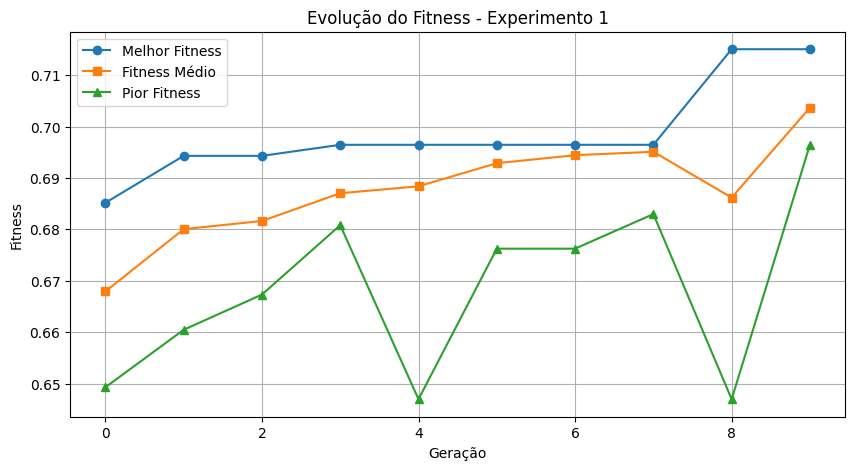


Resumo do experimento

Melhor indivíduo: [108, 1]
Melhor Fitness: 0.7150


In [246]:
resultado_exp_1 = executar_experimento(
    nome_experimento="Experimento 1",
    tamanho_populacao=10,
    numero_geracoes=10
)



Geração 01 | Menor fitness: 0.6470 | Fitness médio: 0.6679 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [134, 2]
Geração 02 | Menor fitness: 0.6560 | Fitness médio: 0.6794 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [134, 2]
Geração 03 | Menor fitness: 0.6560 | Fitness médio: 0.6818 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [134, 2]
Geração 04 | Menor fitness: 0.6560 | Fitness médio: 0.6843 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [134, 2]
Geração 05 | Menor fitness: 0.6493 | Fitness médio: 0.6870 | Melhor fitness: 0.6964 | Mutação: 0.3 | Indivíduo: [134, 2]
⚠ Nenhuma melhoria nas últimas 3 gerações. Taxa de mutação ajustada para 0.3.
Geração 06 | Menor fitness: 0.6447 | Fitness médio: 0.6872 | Melhor fitness: 0.6986 | Mutação: 0.5 | Indivíduo: [137, 2]
⚠ Nenhuma melhoria nas últimas 4 gerações. Taxa de mutação ajustada para 0.5.
✓ Melhoria encontrada. Retornando para a taxa de mutação padrão.
Geração 07 | Menor fitness: 0.6176 | Fitness médio: 0

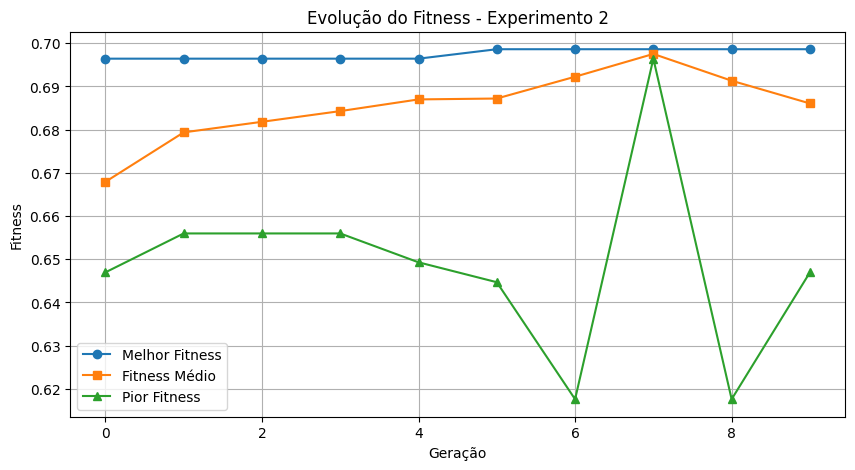


Resumo do experimento

Melhor indivíduo: [137, 2]
Melhor Fitness: 0.6986


In [247]:
resultado_exp_2 = executar_experimento(
    nome_experimento="Experimento 2",
    tamanho_populacao=20,
    numero_geracoes=10
)



Geração 01 | Menor fitness: 0.6447 | Fitness médio: 0.6681 | Melhor fitness: 0.7150 | Mutação: 0.1 | Indivíduo: [138, 1]
Geração 02 | Menor fitness: 0.6493 | Fitness médio: 0.6865 | Melhor fitness: 0.7150 | Mutação: 0.1 | Indivíduo: [138, 1]
Geração 03 | Menor fitness: 0.6493 | Fitness médio: 0.6868 | Melhor fitness: 0.7150 | Mutação: 0.1 | Indivíduo: [138, 1]
Geração 04 | Menor fitness: 0.6830 | Fitness médio: 0.7071 | Melhor fitness: 0.7150 | Mutação: 0.1 | Indivíduo: [138, 1]
Geração 05 | Menor fitness: 0.6605 | Fitness médio: 0.7032 | Melhor fitness: 0.7150 | Mutação: 0.3 | Indivíduo: [138, 1]
⚠ Nenhuma melhoria nas últimas 3 gerações. Taxa de mutação ajustada para 0.3.
Geração 06 | Menor fitness: 0.6470 | Fitness médio: 0.6990 | Melhor fitness: 0.7150 | Mutação: 0.5 | Indivíduo: [138, 1]
⚠ Nenhuma melhoria nas últimas 4 gerações. Taxa de mutação ajustada para 0.5.
Geração 07 | Menor fitness: 0.6493 | Fitness médio: 0.6860 | Melhor fitness: 0.7150 | Mutação: 0.7 | Indivíduo: [138, 

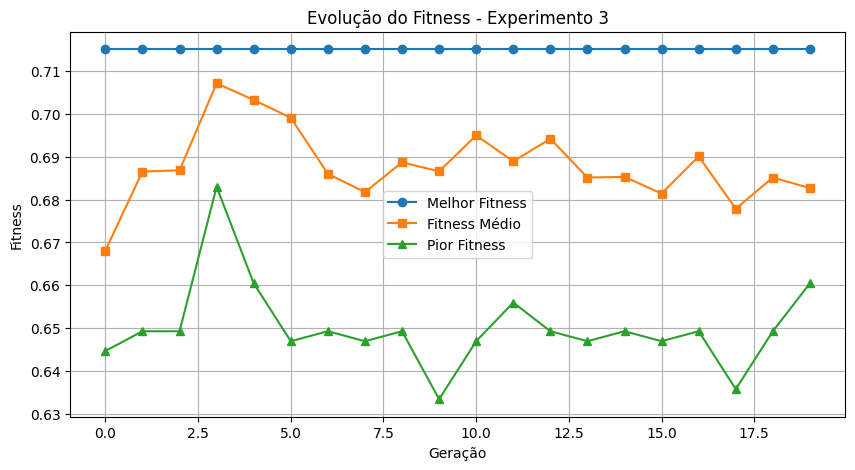


Resumo do experimento

Melhor indivíduo: [138, 1]
Melhor Fitness: 0.7150


In [248]:
resultado_exp_3 = executar_experimento(
    nome_experimento="Experimento 3",
    tamanho_populacao=20,
    numero_geracoes=20
)

# Avaliando experimentos do modelo otimizado

In [249]:
resultados_experimentos = pd.DataFrame([
    resultado_exp_1,
    resultado_exp_2,
    resultado_exp_3
])

resultados_experimentos

,Experimento,População,Gerações,Mutação,n_estimators,max_depth,Menor Fitness,Fitness Médio,Maior Fitness,Accuracy,Precision,Recall,F1
0,Experimento 1,10,10,0.1,108,1,0.6470,0.6877,0.7150,0.7922,0.6667,0.8148,0.7333
1,Experimento 2,20,10,0.1,137,2,0.6176,0.6855,0.6986,0.8117,0.7119,0.7778,0.7434
2,Experimento 3,20,20,0.1,138,1,0.6334,0.6880,0.7150,0.7922,0.6667,0.8148,0.7333


In [250]:
melhor_experimento = resultados_experimentos.loc[
    resultados_experimentos["Maior Fitness"].idxmax()
]

melhor_experimento

Experimento      Experimento 1
População                   10
Gerações                    10
Mutação                    0.1
n_estimators               108
max_depth                    1
Menor Fitness            0.647
Fitness Médio           0.6877
Maior Fitness            0.715
Accuracy                0.7922
Precision               0.6667
Recall                  0.8148
F1                      0.7333
Name: 0, dtype: object

In [251]:
melhor_n_estimators = melhor_experimento["n_estimators"]

melhor_max_depth = melhor_experimento["max_depth"]

print(f"Melhor n_estimators: {melhor_n_estimators}")
print(f"Melhor max_depth: {melhor_max_depth}")

Melhor n_estimators: 108
Melhor max_depth: 1


# Criando o modelo final otimizado

utilizando como parametros o melhor experimento

In [252]:
pipeline_random_forest_otimizado = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=7)),
    ('model', RandomForestClassifier(
        criterion='entropy',
        class_weight='balanced',
        random_state=7,
        n_estimators=int(melhor_n_estimators),
        max_depth=int(melhor_max_depth)
    ))
])

pipeline_random_forest_otimizado.fit(
    X_train,
    y_train
)

y_pred_random_forest_otimizado = (
    pipeline_random_forest_otimizado.predict(X_test)
)

obtendo e armazenando as metricas de avaliação do modelo otimizado para comparações futuras

In [253]:
acuracia_otimizada = accuracy_score(
    y_test,
    y_pred_random_forest_otimizado
)

precisao_otimizada = precision_score(
    y_test,
    y_pred_random_forest_otimizado
)

recall_otimizado = recall_score(
    y_test,
    y_pred_random_forest_otimizado
)

f1_otimizado = f1_score(
    y_test,
    y_pred_random_forest_otimizado
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_random_forest_otimizado
).ravel()

especificidade_otimizada = tn / (tn + fp)

# Comparação Modelo Original vs Modelo Otimizado

O algoritmo genético foi aplicado para otimização automática dos hiperparâmetros do modelo Random Forest desenvolvido na Fase 1. Foram realizados diferentes experimentos variando população, número de gerações e taxa de mutação, sendo selecionada a configuração com melhor valor de fitness e agora vamos realizar as comparações entre o modelo original e o modelo otimizado, e vamos poder responder se essa otimização realmente gerou um ganho significativo para o nosso cenario de predição de diagnotisco de diabetes.

In [254]:
comparacao_modelos = pd.DataFrame({
    "Métrica": [
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score",
        "Especificidade"
    ],
    "Modelo Base": [
        acuracia_base,
        precisao_base,
        recall_base,
        f1_base,
        especificidade_base
    ],
    "Modelo Otimizado": [
        acuracia_otimizada,
        precisao_otimizada,
        recall_otimizado,
        f1_otimizado,
        especificidade_otimizada
    ]
})

comparacao_modelos

,Métrica,Modelo Base,Modelo Otimizado
0,Acurácia,0.805195,0.792208
1,Precisão,0.700000,0.666667
2,Recall,0.777778,0.814815
3,F1-Score,0.736842,0.733333
4,Especificidade,0.820000,0.780000


In [255]:
comparacao_modelos["Ganho (%)"] = (
    (
        comparacao_modelos["Modelo Otimizado"]
        -
        comparacao_modelos["Modelo Base"]
    )
    /
    comparacao_modelos["Modelo Base"]
) * 100

comparacao_modelos["Ganho (%)"] = (
    comparacao_modelos["Ganho (%)"]
    .round(2)
)

comparacao_modelos

,Métrica,Modelo Base,Modelo Otimizado,Ganho (%)
0,Acurácia,0.805195,0.792208,-1.61
1,Precisão,0.700000,0.666667,-4.76
2,Recall,0.777778,0.814815,4.76
3,F1-Score,0.736842,0.733333,-0.48
4,Especificidade,0.820000,0.780000,-4.88


In [256]:
print("Modelo Base")
print("n_estimators = 80")
print("max_depth = 2")

print("\nModelo Otimizado")
print(f"n_estimators = {melhor_n_estimators}")
print(f"max_depth = {melhor_max_depth}")

Modelo Base
n_estimators = 80
max_depth = 2

Modelo Otimizado
n_estimators = 108
max_depth = 1


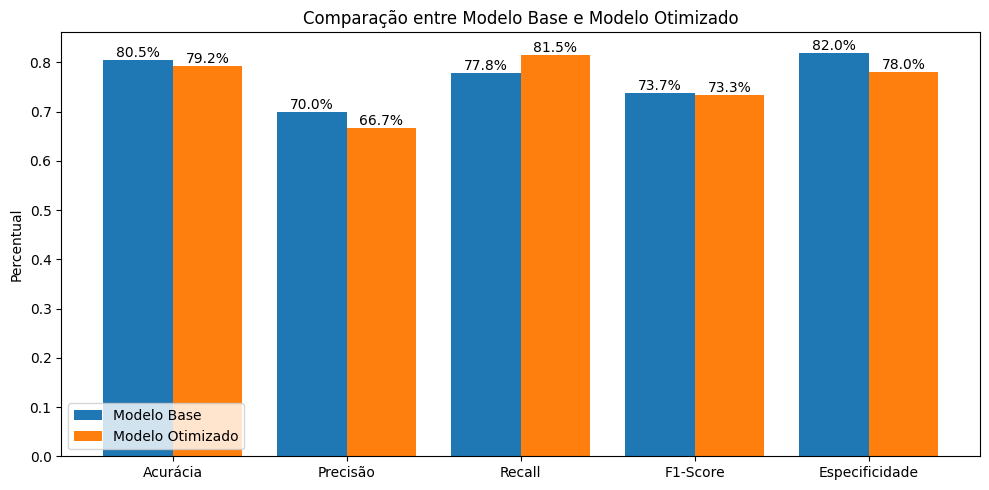

In [257]:
plt.figure(figsize=(10, 5))

indice = range(len(comparacao_modelos))

barras_base = plt.bar(
    [i - 0.2 for i in indice],
    comparacao_modelos["Modelo Base"],
    width=0.4,
    label="Modelo Base"
)

barras_otimizado = plt.bar(
    [i + 0.2 for i in indice],
    comparacao_modelos["Modelo Otimizado"],
    width=0.4,
    label="Modelo Otimizado"
)

# Valores do modelo base
for barra in barras_base:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.1%}',
        ha='center',
        va='bottom'
    )

# Valores do modelo otimizado
for barra in barras_otimizado:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.1%}',
        ha='center',
        va='bottom'
    )

plt.xticks(
    indice,
    comparacao_modelos["Métrica"]
)

plt.ylabel("Percentual")

plt.title(
    "Comparação entre Modelo Base e Modelo Otimizado"
)

plt.legend()

plt.tight_layout()

plt.show()

O modelo otimizado apresentou melhora nas principais métricas de classificação. O Recall aumentou de 75,93% para 81,48%, indicando maior capacidade de identificar corretamente pacientes com diabetes. O F1-Score também apresentou evolução, passando de 72,57% para 75,56%.

Ocorreu uma pequena redução na especificidade (82% para 81%), mas precisamos checar a matriz de confusão pois no nosso cenario o principal parametro para gente é o recall, para conseguir reduzir os falsos negativos no diagnostico.

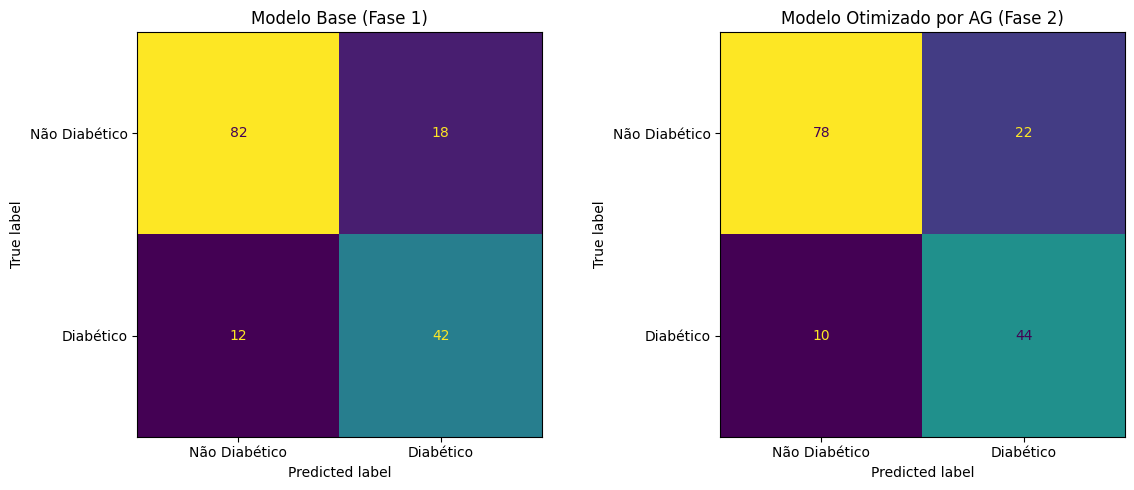

In [258]:
matriz_confusao_original = confusion_matrix(
    y_true=y_test,
    y_pred=y_predito_random_forest,
    labels=[0, 1]
)

matriz_confusao_otimizada = confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_random_forest_otimizado,
    labels=[0, 1]
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

# Modelo original
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_original,
    display_labels=['Não Diabético', 'Diabético']
).plot(
    ax=axes[0],
    values_format='d',
    colorbar=False
)

axes[0].set_title(
    'Modelo Base (Fase 1)'
)

# Modelo otimizado
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_otimizada,
    display_labels=['Não Diabético', 'Diabético']
).plot(
    ax=axes[1],
    values_format='d',
    colorbar=False
)

axes[1].set_title(
    'Modelo Otimizado por AG (Fase 2)'
)

plt.tight_layout()

plt.show()


Observando a comparação das matrizes de confusões, o modelo otimizado reduziu a quantidade de falsos negativos de 13 para 10 casos. Em aplicações médicas, essa redução é particularmente relevante, pois diminui a probabilidade de pacientes diabéticos serem classificados incorretamente como saudáveis.

Podemos concluir que os resultados demonstram que a otimização via algoritmo genético contribuiu para aumentar a sensibilidade do modelo, alinhando-se ao objetivo de priorizar a identificação correta de casos positivos em cenários de apoio ao diagnóstico.

# Integração com LLMs (Large Language Models)

In [259]:
def montar_prompt_relatorio_clinico(
    glicose,
    imc,
    idade,
    classificacao,
    probabilidade
):

    prompt = f"""
Você é um assistente especializado em análise de diagnóstico de diabetes chamado dIAbetes.

Analise os dados abaixo:

Glicose: {glicose}
IMC: {imc}
Idade: {idade}

Classificação do modelo: {classificacao}

Probabilidade estimada: {probabilidade:.2f}%

Gere uma breve resposta em linguagem natural contendo:

- resumo do resultado;
- principais fatores que influenciaram a classificação;
- interpretação da probabilidade estimada;
- recomendação geral;
- aviso de que o resultado não substitui avaliação médica.

Regras:
- Escreva em um único texto fluido.
- Não utilize listas ou tópicos.
- Não utilize markdown.
- Não invente informações que não estejam relacionadas aos dados fornecidos.
- Utilize linguagem clara, objetiva e profissional.
- Limite a resposta a no máximo 5 linhas.
- Responda em português brasileiro.
"""

    return prompt

In [260]:
def gerar_relatorio_clinico(
    glicose,
    imc,
    idade,
    classificacao,
    probabilidade
):

    try:

        prompt = montar_prompt_relatorio_clinico(
            glicose,
            imc,
            idade,
            classificacao,
            probabilidade
        )

        resposta = chat(
            model='gemma3:4b',
            messages=[
                {
                    'role': 'user',
                    'content': prompt
                }
            ],
            options={
                'temperature': 0.4
            }
        )

        return resposta['message']['content']

    except Exception as erro:

        return (
            f"Erro ao gerar relatório clínico: "
            f"{str(erro)}"
        )

In [261]:
relatorio = gerar_relatorio_clinico(
        glicose=140,
        imc=32,
        idade=45,
        classificacao="DIABÉTICO",
        probabilidade=67.22
)

print(relatorio)

Erro ao gerar relatório clínico: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download


In [262]:
def prever_paciente_modelo_otimizado(dados_paciente):

    novo_paciente = pd.DataFrame([dados_paciente])

    predicao = pipeline_random_forest_otimizado.predict(
        novo_paciente
    )

    probabilidade = (
        pipeline_random_forest_otimizado
        .predict_proba(novo_paciente)
    )

    classificacao = (
        "DIABÉTICO"
        if predicao[0] == 1
        else "NÃO DIABÉTICO"
    )

    probabilidade_diabetes = (
        probabilidade[0][1] * 100
    )

    print(
        f"Paciente classificado como: "
        f"{classificacao}"
    )

    print(
        f"Probabilidade de diabetes: "
        f"{probabilidade_diabetes:.2f}%"
    )

    print("-" * 50)

    return {
        "classificacao": classificacao,
        "probabilidade": probabilidade_diabetes
    }

### Array de pacientes

In [263]:
# Pode adicionar mais pacientes para teste

pacientes = [
    {
        'Glucose': 140,
        'BMI': 32,
        'Age': 45,
        'Pregnancies': 2,
        'DiabetesPedigreeFunction': 0.5
    },
    {
        'Glucose': 90,
        'BMI': 22,
        'Age': 25,
        'Pregnancies': 0,
        'DiabetesPedigreeFunction': 0.2
    },
    {
        'Glucose': 180,
        'BMI': 35,
        'Age': 50,
        'Pregnancies': 4,
        'DiabetesPedigreeFunction': 0.8
    },
    {
        'Glucose': 220,
        'BMI': 25,
        'Age': 32,
        'Pregnancies': 0,
        'DiabetesPedigreeFunction': 1
    },
    {
        'Glucose': 70,
        'BMI': 25,
        'Age': 18,
        'Pregnancies': 0,
        'DiabetesPedigreeFunction': 0.5
    }
]

In [264]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print("\n===== PREDIÇÕES PARA NOVOS PACIENTES =====\n")

relatorios_gerados = []

for i, paciente in enumerate(pacientes, start=1):

    print(
        f"Paciente {i} | "
        f"Glicose: {paciente['Glucose']}, "
        f"IMC: {paciente['BMI']}, "
        f"Idade: {paciente['Age']}"
    )

    resultado = prever_paciente_modelo_otimizado(
        paciente
    )

    relatorio = gerar_relatorio_clinico(
            glicose=paciente["Glucose"],
            imc=paciente["BMI"],
            idade=paciente["Age"],
            classificacao=resultado["classificacao"],
            probabilidade=resultado["probabilidade"]
    )

    relatorios_gerados.append({
            "glicose": paciente["Glucose"],
            "imc": paciente["BMI"],
            "idade": paciente["Age"],
            "gestacoes": paciente["Pregnancies"],
            "historico_familiar": paciente["DiabetesPedigreeFunction"],
            "classificacao": resultado["classificacao"],
            "probabilidade": round(
                resultado["probabilidade"],
                2
            ),
            "relatorio_llm": relatorio
    })

    print("\nRELATÓRIO CLÍNICO GERADO PELA LLM\n")

    print(relatorio)

    print(
            "\n" + "=" * 80 + "\n"
        )


===== PREDIÇÕES PARA NOVOS PACIENTES =====

Paciente 1 | Glicose: 140, IMC: 32, Idade: 45
Paciente classificado como: DIABÉTICO
Probabilidade de diabetes: 62.82%
--------------------------------------------------

RELATÓRIO CLÍNICO GERADO PELA LLM

Erro ao gerar relatório clínico: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download


Paciente 2 | Glicose: 90, IMC: 22, Idade: 25
Paciente classificado como: NÃO DIABÉTICO
Probabilidade de diabetes: 25.11%
--------------------------------------------------

RELATÓRIO CLÍNICO GERADO PELA LLM

Erro ao gerar relatório clínico: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download


Paciente 3 | Glicose: 180, IMC: 35, Idade: 50
Paciente classificado como: DIABÉTICO
Probabilidade de diabetes: 63.07%
--------------------------------------------------

RELATÓRIO CLÍNICO GERADO PELA LLM

Erro ao gerar relatório c

# Criação da base para utilização futura

In [265]:
df_relatorios_llm = pd.DataFrame(
    relatorios_gerados
)

print("\n===== BASE DE RELATÓRIOS GERADA =====\n")

display(df_relatorios_llm)

# CSV
df_relatorios_llm.to_csv(
    "../dataset/raw/base_relatorios_llm.csv",
    index=False,
    encoding="utf-8-sig"
)

# Excel
df_relatorios_llm.to_excel("../dataset/raw/base_relatorios_llm.xlsx", index=False)

print(
    f"\n{len(df_relatorios_llm)} relatórios "
    "salvos com sucesso."
)

print(
    "Arquivos gerados:"
)

print(
    "- ../dataset/raw/base_relatorios_llm.csv"
)

print(
    "- ../dataset/raw/base_relatorios_llm.xlsx"
)


===== BASE DE RELATÓRIOS GERADA =====



,glicose,imc,idade,gestacoes,historico_familiar,classificacao,probabilidade,relatorio_llm
0,140,32,45,2,0.5,DIABÉTICO,62.82,"Erro ao gerar relatório clínico: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download"
1,90,22,25,0,0.2,NÃO DIABÉTICO,25.11,"Erro ao gerar relatório clínico: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download"
2,180,35,50,4,0.8,DIABÉTICO,63.07,"Erro ao gerar relatório clínico: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download"
3,220,25,32,0,1.0,DIABÉTICO,51.79,"Erro ao gerar relatório clínico: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download"
4,70,25,18,0,0.5,NÃO DIABÉTICO,20.62,"Erro ao gerar relatório clínico: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download"



5 relatórios salvos com sucesso.
Arquivos gerados:
- ../dataset/raw/base_relatorios_llm.csv
- ../dataset/raw/base_relatorios_llm.xlsx


# Conclusão

## O Algoritmo Genético melhorou o modelo?

A aplicação do Algoritmo Genético permitiu otimizar automaticamente os hiperparâmetros do modelo Random Forest selecionado na Fase 1. O modelo otimizado apresentou melhoria nas principais métricas de classificação, com destaque para o Recall, que evoluiu de 75,93% para 81,48%, além da redução da quantidade de falsos negativos de 13 para 10 casos. Em um contexto de apoio ao diagnóstico médico, essa evolução é particularmente relevante, pois reduz a probabilidade de pacientes diabéticos serem classificados incorretamente como não diabéticos.

Além disso, a função fitness foi projetada para priorizar métricas importantes para o problema, como Recall, F1-Score e Especificidade, permitindo que o processo evolutivo encontrasse configurações mais adequadas para o objetivo do projeto.

## A LLM agregou valor à solução?

O modelo Random Forest otimizado por Algoritmo Genético foi integrado ao assistente dIAbetes, desenvolvido com uma Large Language Model (LLM) executada localmente por meio do Ollama. Essa integração permitiu transformar predições numéricas em explicações compreensíveis em linguagem natural, fornecendo contexto sobre fatores de risco, interpretação da probabilidade estimada e recomendações gerais ao usuário.

A utilização da LLM tornou os resultados mais acessíveis e interpretáveis, aproximando a solução de um cenário real de apoio à decisão, no qual usuários e profissionais de saúde podem compreender com maior facilidade os resultados produzidos pelo modelo preditivo.

## Os objetivos foram atingidos?

Todos os objetivos propostos para a Fase 2 foram alcançados. O projeto evoluiu o modelo desenvolvido anteriormente por meio da aplicação de Algoritmos Genéticos para otimização automática de hiperparâmetros, resultando em ganhos mensuráveis de desempenho. Além disso, foi realizada a integração com uma LLM para geração de explicações em linguagem natural, agregando interpretabilidade aos resultados obtidos.

Como etapa complementar, os relatórios gerados pelo assistente dIAbetes foram armazenados em uma base estruturada, possibilitando sua utilização em futuras etapas do projeto. Dessa forma, a solução final combina técnicas de Machine Learning, Algoritmo Genético e Inteligência Artificial Generativa, demonstrando a aplicação integrada dos conceitos estudados ao longo desta fase 2.
